<div align=center>

<br/>
<font size=4>
        <b>
        In the Name of God
    </b>
    </font>
    <br/>
    <br/>
    <font align=center size=5>
        <br/>
        Project
        <br/><br/>
        <font color=blue size=5>
            Face Recognition
        </font>
        <br/>
        <br/>
    </font>
    <hr/>
    <font size=4>
         Dr. Mazlaghani
        <br/>
        <br/>
        <br/>
        Winter 2023
        <br/>
        <br/>
    </font>
    <br/>
    <br/>
    <br/>
</div>

In [498]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import sys
import cv2
from numpy import linalg as LA
import random
from scipy.ndimage import rotate

<div dir="rtl">
    <h1>
        تشخیص چهره
    </h1>
</div>

<div dir="rtl" style="font-size:18px"> 
    در الگوریتم‌های تشخیص چهره، درون عکس‌ها به دنبال تشخیص خصوصیت‌های خاص عکس بودند. به طور مثال چشم، بینی و ...
     که می‌توانست حاکی از وجود چهره در عکس باشند. واضح است که چنین روش‌هایی هزینه‌بر و در موارد زیادی نادقیق هستند.
    <br/>
    <br/>
    در این پروژه به دنبال پیاده سازی روشی هستیم که بتوانیم این تشخیص را با استفاده از مفاهیم آموخته شده به نحو موثری انجام دهیم.
    </div>

## Load Data (10 points)



<br/>

<div dir="rtl" style="font-size:18px">
    قبل از اینکه درباره پیاده‌سازی این الگوریتم صحبت کنیم لازم است داده‌هایی که مورد استفاده قرار می‌دهیم را داشته باشیم.
    داده‌های مورد نظر در زیپ مربوطه همراه این نوتبوک قرار گرفته‌است.
    <br/>
    دقت کنید که این دیتاست شامل تصاویر مربوط به چهره 200 فرد است.
    هر کدام از افراد دو عکس یکی حالت طبیعی و یکی خندان دارند.
    پس در کل 400 عکس داریم.
    ابتدا تمام عکس‌ها را لود کنید و داشته باشید که در ادامه به آن‌ها نیاز پیدا می‌کنید.
    <br/>
    <br/>
    در نهایت برای این که مطمئن شوید که دیتا را درست لود کرده‌اید،
    به طور رندوم 5 تا از این چهره‌ها را در دو حالت خندان و عادی نمایش دهید. برای اینکار میتوانید از تابع imshow از لایبرری matplotlib استفاده کنید.
    <br/>
</div>

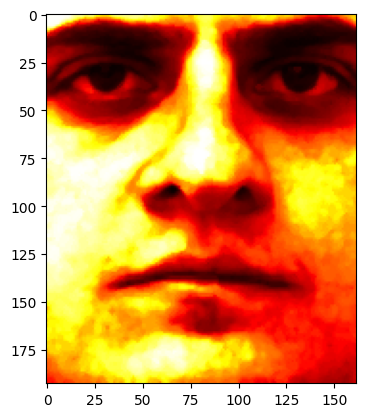

In [499]:
img_1a = np.asarray(Image.open('./datasets/1a.jpg'))
plt.imshow(img_1a, cmap="hot")

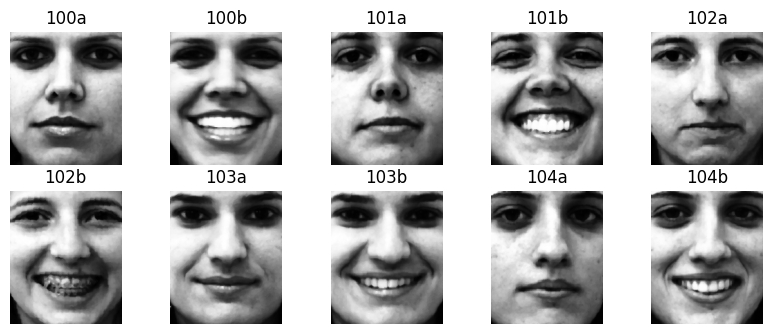

In [500]:
directory = os.listdir('./datasets/')
plt.figure(figsize=(10, 10))
counter = 0

for each in directory:
    if each.endswith('.jpg'):
        full_path = os.path.join('./datasets/', each)
        img = np.asarray(Image.open(full_path))
        plt.subplot(5, 5, counter + 1)
        plt.title(each.split('.')[0])
        plt.imshow(img, cmap="gray")
        plt.axis('off')
        counter += 1
        if counter >= 10:
            break

<br/>
<div dir="rtl" style="font-size:18px">
حال فعلا تنها با عکس‌های چهره طبیعی کار داریم.
    190 تا عکس اول از آن را در نظر بگیرید
     هر کدام را به صورت یک وکتور تک بعدی $\Gamma_i$ در بیاورید.
     در نهایت ماتریس حاصل از داده‌ها که $\Gamma$ است
    را تشکیل دهید. دقت کنید که ستون $i$ ام این ماتریس
    $\Gamma_i$ است.
    <br/>
<div/>

In [501]:
matrix_1a = np.asarray([img_1a])
matrix_1a

array([[[254, 252, 252, ..., 175, 169, 164],
        [255, 253, 253, ..., 168, 176, 164],
        [254, 254, 254, ..., 170, 175, 175],
        ...,
        [104, 100,  99, ...,  65,  72,  77],
        [ 96, 100, 100, ...,  65,  70,  70],
        [ 96, 100, 100, ...,  65,  70,  70]]],
      shape=(1, 193, 162), dtype=uint8)

In [502]:
flat_1a = matrix_1a.flatten()
flat_1a

array([254, 252, 252, ...,  65,  70,  70], shape=(31266,), dtype=uint8)

In [503]:
cols_flat_1a = flat_1a.reshape(-1,1)
cols_flat_1a

array([[254],
       [252],
       [252],
       ...,
       [ 65],
       [ 70],
       [ 70]], shape=(31266, 1), dtype=uint8)

In [504]:
img_1b = np.asarray(Image.open('./datasets/1b.jpg'))
matrix_1b = np.asarray([img_1b])
flat_1b = matrix_1b.flatten()
cols_flat_1b = flat_1b.reshape(-1,1)
cols_flat_1b

array([[250],
       [252],
       [252],
       ...,
       [ 70],
       [ 76],
       [ 78]], shape=(31266, 1), dtype=uint8)

In [505]:
np.append(cols_flat_1a,cols_flat_1b, axis=1)

array([[254, 250],
       [252, 252],
       [252, 252],
       ...,
       [ 65,  70],
       [ 70,  76],
       [ 70,  78]], shape=(31266, 2), dtype=uint8)

In [506]:
images_matrix = np.zeros((31266,0))
for each in directory:
    if each.endswith('.jpg'):
        full_path = os.path.join('./datasets/', each)
        img = np.asarray(Image.open(full_path))
        flat = img.flatten()
        cols_flat = flat.reshape(-1,1)
        images_matrix = np.append(images_matrix,cols_flat, axis=1)

images_matrix

array([[190., 187., 161., ...,  29., 209., 202.],
       [202., 203., 185., ...,  33., 225., 216.],
       [216., 216., 200., ...,  44., 224., 222.],
       ...,
       [ 23.,   2.,   3., ...,   2.,  95., 171.],
       [ 23.,   2.,   2., ...,   2.,  91., 202.],
       [ 19.,   2.,   1., ...,   2.,  91., 235.]], shape=(31266, 400))

this searching in the path with np.append in for loop gets me a lot of time. so i want to find the best and fastest way.

In [507]:
num_img = len(directory)
print(num_img)
h, w, c = 128, 128, 3
img_matrix = np.empty((num_img, h, w, c), dtype= np.uint8)

for i, file_name in enumerate(directory):
    img_path = os.path.join('./datasets', file_name)
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (w,h))
    img_matrix[i] = img_resized

img_matrix.shape

400


(400, 128, 128, 3)

In [508]:
NUM_IMAGES = 400
FEATURE_DIM = 31266

final_matrix = np.empty((FEATURE_DIM, NUM_IMAGES), dtype=np.float32, order='F')
i = 0
for each in directory:
    if each.endswith('.jpg'):
        full_path = os.path.join('./datasets/', each)
        img = np.asarray(Image.open(full_path))
        flat = img.flatten()
        cols_flat = flat.T
        final_matrix[:, i] = cols_flat
        i+=1

final_matrix.shape

(31266, 400)

# PCA

<div dir="rtl" style="font-size:18px; text-align:right;">

الگوریتم <strong>Principal Component Analysis</strong> یا همان <strong>PCA</strong> یک روش برای کاهش ابعاد داده‌ی موردنظر است که در حوزه یادگیری ماشین و علوم داده کاربرد فراوان دارد. با کاهش ابعاد، سادگی را افزایش داده و در عین حال همانگونه که انتظار می‌رود ورودی با کاهش دقت همراه خواهد شد. در الگوریتم <strong>PCA</strong> تلاش بر این است که در عین کاهش ابعاد، کمترین میزان اطلاعات را از دست بدهیم. پیشنهاد می‌شود قبل از انجام پروژه مطالعات بیشتری در رابطه با این الگوریتم داشته باشید.
<br/>
<br/>
در ادامه‌ی بخش‌ها می‌خواهیم <strong>PCA</strong> را پیاده‌سازی کنیم. گفتیم که برای تشخیص چهره‌ها به دنبال پیدا کردن مشخصه‌های خاص درون هر عکس هستیم. این مشخصه‌ها ممکن است ترکیبی از چند ویژگی درون عکس باشند، یا حتی ویژگی‌هایی باشند که به طور طبیعی قادر به تشخیص آنها نیستیم. در اینجا با استفاده از الگوریتم <strong>PCA</strong> در تلاش برای پیدا کردن همچین ویژگی‌هایی هستیم.
<br/>
<br/>
با <strong>PCA</strong> قرار است کار زیر را انجام دهیم:
<br/>
<br/>
فرض کنید هر عکس به صورت یک آرایه دو بعدی $N \times M$ باشد، بنابراین هر عکس را می‌توان با یک بردار به طول $N \times M$ نشان دهیم، پس در یک فضای $N \times M$ بعدی قرار دارد. فرض کنید $W$ فضایی باشد که تمامی عکس‌های صورت در آن قرار دارند، اسم آن را <code>Face Space</code> بگذارید. در اینجا به دنبال پیدا کردن $K$ بردار عمود بر هم هستیم که فضای $W$ را <code>Span</code> می‌کنند.

</div>


## Mean image (5 points)

<div dir="rtl" style="font-size:18px">
    
<div/>

<div dir="rtl" style="font-size:18px; text-align:right;">

در این قسمت برای نرمالایز کردن نیاز به **mean image** داریم. آن را بدست آورید و تصویر آن را نمایش هم دهید.

$$
\Psi = \frac{1}{n}\sum_{i = 1}^{n} \Gamma_i
$$

در اینجا $n$ تعداد داده‌های شماست. دقت کنید فعلا کل کار ما بر روی 190 عکس چهره طبیعی است.

</div>


In [509]:
NUM_IMAGES = 190
FEATURE_DIM = 31266

final_matrix = np.empty((FEATURE_DIM, NUM_IMAGES), dtype=np.float32, order='F')
i = 0
for each in directory[0:190]:
    if each.endswith('.jpg'):
        full_path = os.path.join('./datasets/', each)
        img = np.asarray(Image.open(full_path))
        flat = img.flatten()
        cols_flat = flat.T
        final_matrix[:, i] = cols_flat
        i+=1

final_matrix.shape

(31266, 190)

In [510]:
mean_matrix = np.mean(final_matrix, axis=1, keepdims=True)
mean_matrix.shape

(31266, 1)

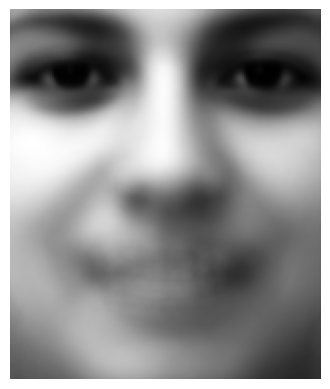

In [511]:
plt.imshow(mean_matrix.reshape(193, 162), cmap='gray')
plt.axis('off')
plt.show()

In [512]:
A = final_matrix - mean_matrix
A

array([[ 31.868423 ,  28.868423 ,   2.8684235, ...,  86.86842  ,
        -41.131577 ,  86.86842  ],
       [ 43.631577 ,  44.631577 ,  26.631577 , ...,  83.63158  ,
        -35.368423 ,  84.63158  ],
       [ 56.98947  ,  56.98947  ,  40.98947  , ...,  77.98947  ,
        -39.01053  ,  86.98947  ],
       ...,
       [-26.605263 , -47.605263 , -46.605263 , ..., 108.39474  ,
        -36.605263 , -27.605263 ],
       [-26.610527 , -47.610527 , -47.610527 , ..., 108.38947  ,
        -30.610527 , -21.610527 ],
       [-31.384209 , -48.38421  , -49.38421  , ..., 158.61578  ,
        -27.384209 , -19.384209 ]], shape=(31266, 190), dtype=float32)

## Cov Matrix (15 points)

<div dir="rtl" style="font-size:18px">
    
<div/>

<div dir="rtl" style="font-size:18px; text-align:right;">

در این قسمت باید ماتریس کوواریانس را به صورت زیر تعریف کنید:

$$
\Phi_i = \Gamma_i - \Psi
$$

$$
A = [ \Phi_1, \Phi_2, \dots, \Phi_n ]
$$

$$
C = A A^T
$$

حال بردار ویژه‌های ماتریس $C$ به ترتیب بزرگی مقدار ویژه‌های متناظرشان، <strong>Principal Components</strong> هایی هستند که ما می‌خواهیم.
<br/>
دقت کنید که ماتریس $C$ ماتریسی $N^2 \times N^2$ می‌باشد، سعی کنید روش بهینه‌ای برای پیدا کردن بردار ویژه‌های آن پیاده‌سازی کنید. به عنوان راهنمایی از $A^T A$ کمک بگیرید.
<br/>
مقدار این مقادیر ویژه را سورت کنید و درون یک نمودار نشان دهید. 
<br/>
بعد از سورت کردن مقدار ویژه‌ها، بردار ویژه متناظر با ۵ مقدار ویژه اول را بکشید. این بردارهای ویژه را <code>eigen face</code> می‌نامیم.
<br/>
در نهایت با کمی مطالعه معیاری را انتخاب کنید و تعداد مورد نیاز از <strong>Principal Component</strong> ها از نظرتان را مشخص نمایید و آن تعداد بردار ویژه را انتخاب کنید. این عدد را $K$ در نظر بگیرید. همچنین ماتریس شامل <strong>PC</strong> ها را $U$ در نظر بگیرید.

</div>


In [513]:
L = np.dot(A.T , A)
print(L.shape)
eigenvalues, eigenvectors = LA.eig(L)
print(eigenvalues)
print(eigenvectors)

(190, 190)
[ 2.3132365e+09  1.2510620e+09  7.0150240e+08  5.7194560e+08
  5.2909005e+08  5.2172973e+08  4.4364781e+08  3.8375667e+08
  3.5179430e+08  2.8520112e+08  2.5326634e+08  2.2563350e+08
  2.0985262e+08  2.0634235e+08  1.8042754e+08  1.7208382e+08
  1.5006592e+08  1.3730712e+08  1.3641237e+08  1.2689804e+08
  1.1722797e+08  1.0830153e+08  9.7532552e+07  8.9609064e+07
  8.6115088e+07  8.2649192e+07  8.0486952e+07  7.7792944e+07
  7.5079752e+07  7.1577544e+07  6.7809544e+07  6.3264780e+07
  6.1805280e+07  5.8407864e+07  5.6824272e+07  5.3504460e+07
  4.9852996e+07  4.8203720e+07  4.6092460e+07  4.5220080e+07
  4.4615516e+07  4.2879928e+07  4.1904752e+07  4.1501892e+07
  4.1199260e+07  4.0030144e+07  3.7915336e+07  3.5923492e+07
  3.5507516e+07  3.4344300e+07  3.3453632e+07  3.2035306e+07
  3.0989584e+07  3.0395260e+07  2.8730512e+07  2.8260722e+07
  2.7548088e+07  2.7290498e+07  2.6724562e+07  2.5806280e+07
  2.5548836e+07  2.4889498e+07  2.3657502e+07  2.3071762e+07
  2.2876998e+

In [514]:
U = np.dot(A,eigenvectors)
U

array([[-1.2875851e+02,  2.5712883e+01, -1.1283237e+01, ...,
        -4.9812157e+01, -1.1953870e+01,  2.4490751e+01],
       [-1.4686275e+02,  4.6248749e+01,  2.5081356e+01, ...,
        -5.3750191e+01, -2.7706753e+01,  4.7592079e+01],
       [-1.6239087e+02,  2.5392403e+01,  7.6448875e+01, ...,
        -7.4588036e+01, -3.1856718e+01,  3.0640436e+01],
       ...,
       [ 1.0086101e+02, -3.0318286e+02, -3.9141373e+01, ...,
         1.5058509e-01,  7.7164292e+00, -1.6642698e+01],
       [ 1.0736786e+02, -2.9411627e+02, -5.7761768e+01, ...,
        -1.2465177e+01, -2.9326508e+00, -1.1624574e+01],
       [ 1.0303914e+02, -2.8768225e+02, -6.7496834e+01, ...,
        -1.5485049e+01, -2.2584143e+00, -1.1433464e+01]],
      shape=(31266, 190), dtype=float32)

In [515]:
print(U.shape)
U_l2_norm = LA.norm(U,ord=None, axis=0, keepdims=True)
U = U / U_l2_norm
U

(31266, 190)


array([[-2.6771161e-03,  7.2696205e-04, -4.2601078e-04, ...,
        -2.2694089e-02, -5.5669365e-03,  1.1162151e-02],
       [-3.0535350e-03,  1.3075579e-03,  9.4697363e-04, ...,
        -2.4488231e-02, -1.2903080e-02,  2.1691045e-02],
       [-3.3763919e-03,  7.1790133e-04,  2.8864096e-03, ...,
        -3.3981815e-02, -1.4835726e-02,  1.3964993e-02],
       ...,
       [ 2.0970779e-03, -8.5716732e-03, -1.4778246e-03, ...,
         6.8605565e-05,  3.5935538e-03, -7.5852433e-03],
       [ 2.2323667e-03, -8.3153397e-03, -2.1808578e-03, ...,
        -5.6790519e-03, -1.3657403e-03, -5.2981325e-03],
       [ 2.1423651e-03, -8.1334356e-03, -2.5484157e-03, ...,
        -7.0548858e-03, -1.0517472e-03, -5.2110306e-03]],
      shape=(31266, 190), dtype=float32)

In [516]:
idx = eigenvalues.argsort()[::-1]
print(idx)
eigenvalues = eigenvalues[idx]
U_sorted = U[:,idx]
print(U_sorted.shape, eigenvalues.shape)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  67  65  66  69  70  71  72
  73  74  75  76  77  78  79  81  80  82  83  84  85  86  87  88  89  91
  92  93  90  94  95  96  97  98  99 100 101 102 105 104 103 108 109 110
 107 106 114 115 116 117 120 121 124 130 125 131 132 133 138 140 139 141
 142 150 151 154 158 159 185 156 155 157 164 166 165 167 168 184 171 172
 173 174 182 175 183 187 189 176 188 177 186 179 181 178 180 163 162 170
 169 161 160 153 152 144 145 146 147 149 148 143 137 136 135 134 129 128
 127 126 123 122 119 118 113 112 111  68]
(31266, 190) (190,)


In [517]:
K = 150
eigenface = U_sorted[:,:K]
eigenface.shape


(31266, 150)

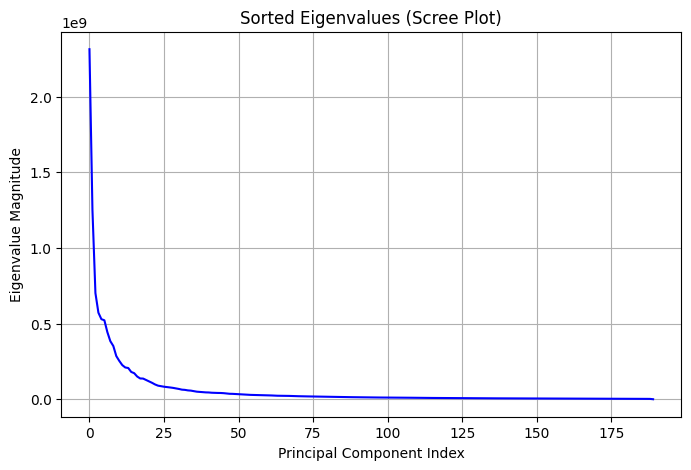

In [518]:
plt.figure(figsize=(8, 5))
plt.plot(eigenvalues, color='b')
plt.title("Sorted Eigenvalues (Scree Plot)")
plt.xlabel("Principal Component Index")
plt.ylabel("Eigenvalue Magnitude")
plt.grid(True)
plt.show()

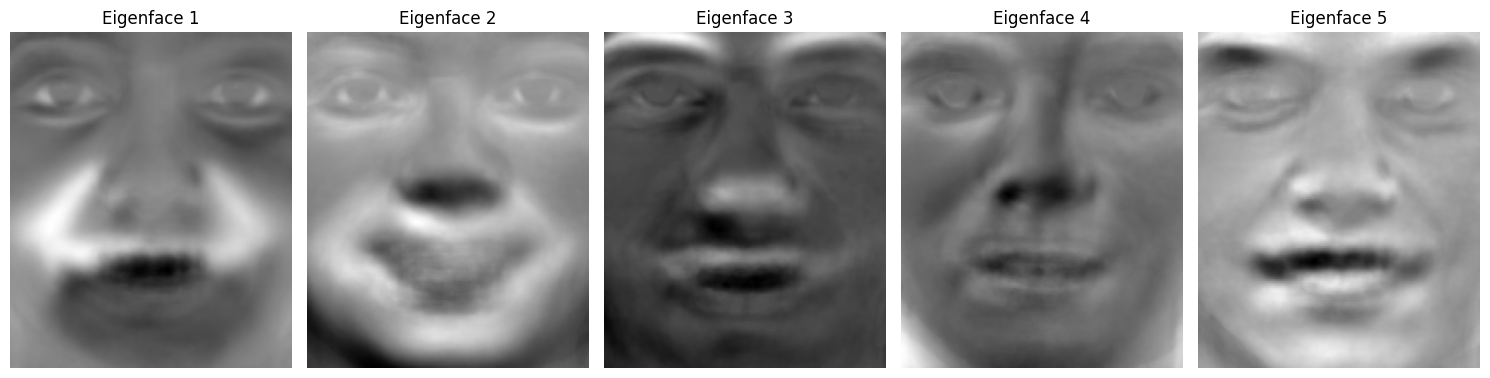

In [519]:
plt.figure(figsize=(15, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    ef_img = U_sorted[:, i].reshape(193, 162)
    plt.imshow(ef_img, cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Reconstruction images (20 points)

<div dir="rtl" style="font-size:18px; text-align:right;">

در این قسمت قرار است که تابعی بنویسید که عکسی را به همراه <strong>Principal Components</strong> های مورد نظر بگیرد و آن را دوباره با آن <strong>PC</strong> ها بازسازی کند. برای نحوه‌ی انجام این کار از روابط زیر کمک بگیرید.

$$
W = U^T(\Gamma - \Psi)
$$
$$
rec = UW + \Psi
$$

دقت کنید که $\Gamma$ اینجا عکس ورودی است.

</div>


In [520]:
W = np.dot(eigenface.T,A)
W.shape

(150, 190)

In [521]:
A_rec= np.dot(eigenface,W)
A_rec.shape

(31266, 190)

In [522]:
final_rec = A_rec + mean_matrix
final_rec

array([[202.81917  , 171.868    , 187.78258  , ..., 257.49884  ,
        117.26757  , 253.29675  ],
       [208.96275  , 194.63187  , 211.3734   , ..., 247.29657  ,
        126.19088  , 251.29823  ],
       [219.67206  , 212.35164  , 214.56134  , ..., 237.2858   ,
        123.67131  , 246.92683  ],
       ...,
       [ 14.835766 ,   3.5678406,   2.700222 , ..., 158.68274  ,
         14.036152 ,  12.366032 ],
       [ 16.87574  ,  -4.5404854,  -1.9120407, ..., 159.3136   ,
         17.761314 ,  21.365137 ],
       [ 12.684834 ,  -8.818466 ,  -1.0778084, ..., 207.26831  ,
         24.743078 ,  21.461243 ]], shape=(31266, 190), dtype=float32)

In [523]:
# print(A[:,:1])
# print(final_matrix[:,:1])
print(final_rec[:,:1])
print(final_rec.shape)
print(final_matrix.shape)
ax1 = final_rec[:,:1].reshape(1,-1)
ax2 = final_matrix[:,:1].reshape(1,-1)
print(ax1.shape)
print(ax2.shape)
ax1 = np.reshape(ax1, (193, 162))
ax2 = np.reshape(ax2, (193, 162))


[[202.81917 ]
 [208.96275 ]
 [219.67206 ]
 ...
 [ 14.835766]
 [ 16.87574 ]
 [ 12.684834]]
(31266, 190)
(31266, 190)
(1, 31266)
(1, 31266)


<div dir="rtl" style="font-size:18px">
    
<div/>

In [524]:
final_matrix[:,:1]

array([[190.],
       [202.],
       [216.],
       ...,
       [ 23.],
       [ 23.],
       [ 19.]], shape=(31266, 1), dtype=float32)

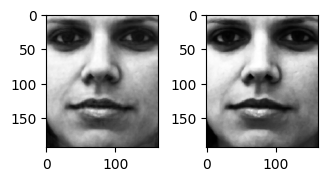

In [525]:
plt.figure(figsize=(10, 10))
plt.subplot(5, 5,1)
plt.imshow(ax1, cmap="gray")
plt.subplot(5, 5,2)
plt.imshow(ax2, cmap="gray")
plt.show()


In [526]:
def reconstruct_image(orig, pcs, mean_matrix):
    """
    A function to reconstruct the original image with the given PCs
    Arguments
    orig - Original image to perform reconstruction on
    pcs  - The principal components to use for the reconstruction
    
    Returns
    recon - The reconstruction of the orig from pcs
    mse   - The Mean Squared Error of the recon with orig
    """
    recon = None
    mse = None
    # todo
    orig =orig - mean_matrix
    W = np.dot(pcs.T , orig)
    recon = np.dot(pcs, W)
    recon = recon + mean_matrix
    
    mse = np.square(np.subtract(orig,recon)).mean()
    
    return recon, mse

In [527]:
rec, mse_rec = reconstruct_image(final_matrix ,eigenface ,mean_matrix)
print(rec[:,2:3], mse_rec)

[[187.78258  ]
 [211.3734   ]
 [214.56134  ]
 ...
 [  2.700222 ]
 [ -1.9120407]
 [ -1.0778084]] 20024.422


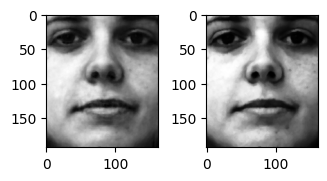

In [528]:
ax3 = rec[:,2:3].reshape(1,-1)
ax3 = np.reshape(ax3, (193, 162))

ax4 = final_matrix[:,2:3].reshape(1,-1)
ax4 = np.reshape(ax4, (193, 162))

plt.figure(figsize=(10, 10))
plt.subplot(5, 5,1)
plt.imshow(ax3, cmap="gray")
plt.subplot(5, 5,2)
plt.imshow(ax4, cmap="gray")
plt.show()

<div dir="rtl" style="font-size:18px; text-align:right;">

(بخش ب)
<br/>
حال یکی از عکس‌های دیتاستی که تا الان روی آن کار کردیم (شامل ۱۹۰ عکس طبیعی) را به صورت رندم انتخاب کنید. برای آن عکس به ازای تمام حالت‌های انتخاب $K$ عملیات بازسازی را انجام دهید.
<br/>
کمترین و بیشترین <strong>MSE</strong> را به دست آورید.
<br/>
<strong>MSE</strong> را برای $K$ ای که در قسمت قبل انتخاب کردید محاسبه نمایید.
<br/>
سپس نمودار <strong>MSE - number of largest principal components</strong> را رسم کنید.
<br/>
در مرحله‌ی بعد برای یک عکس رندم دیگر از دیتاست، عکس اصلی را همراه عکس‌هایی که از بازسازی با در نظر گرفتن ۵ انتخاب مختلف برای $K$ که کل محدوده تعداد <code>eigen face</code> ها را پوشش دهد، رسم کنید.
<br/>
نتایج خود را از کارهایی که این بخش انجام دادید و از روی خروجی‌های بدست آمده شرح دهید.

</div>


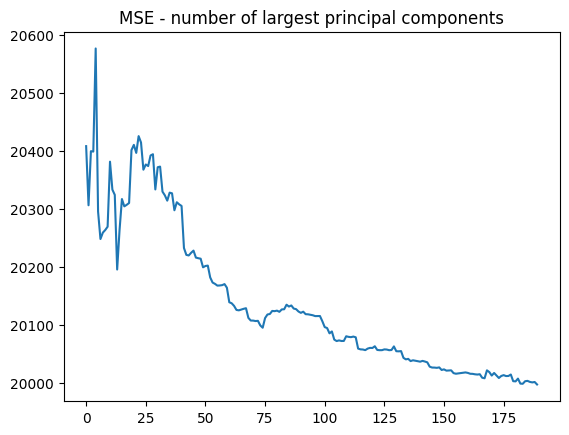

In [529]:
mse_list = []
for k in range(1,191):
    eigenface = U_sorted[:,:k]
    rec, mse_rec = reconstruct_image(final_matrix[:, 50:51] ,eigenface ,mean_matrix)
    mse_list.append(mse_rec)
# print(mse_list)
plt.title("MSE - number of largest principal components")
plt.plot(mse_list)

In [530]:
print(f"MAX mse k: {mse_list.index(max(mse_list))+1} with mse: {max(mse_list)}")
print(f"Min mse k: {mse_list.index(min(mse_list))+1} with mse: {min(mse_list)}")

MAX mse k: 5 with mse: 20577.130859375
Min mse k: 190 with mse: 19997.12109375


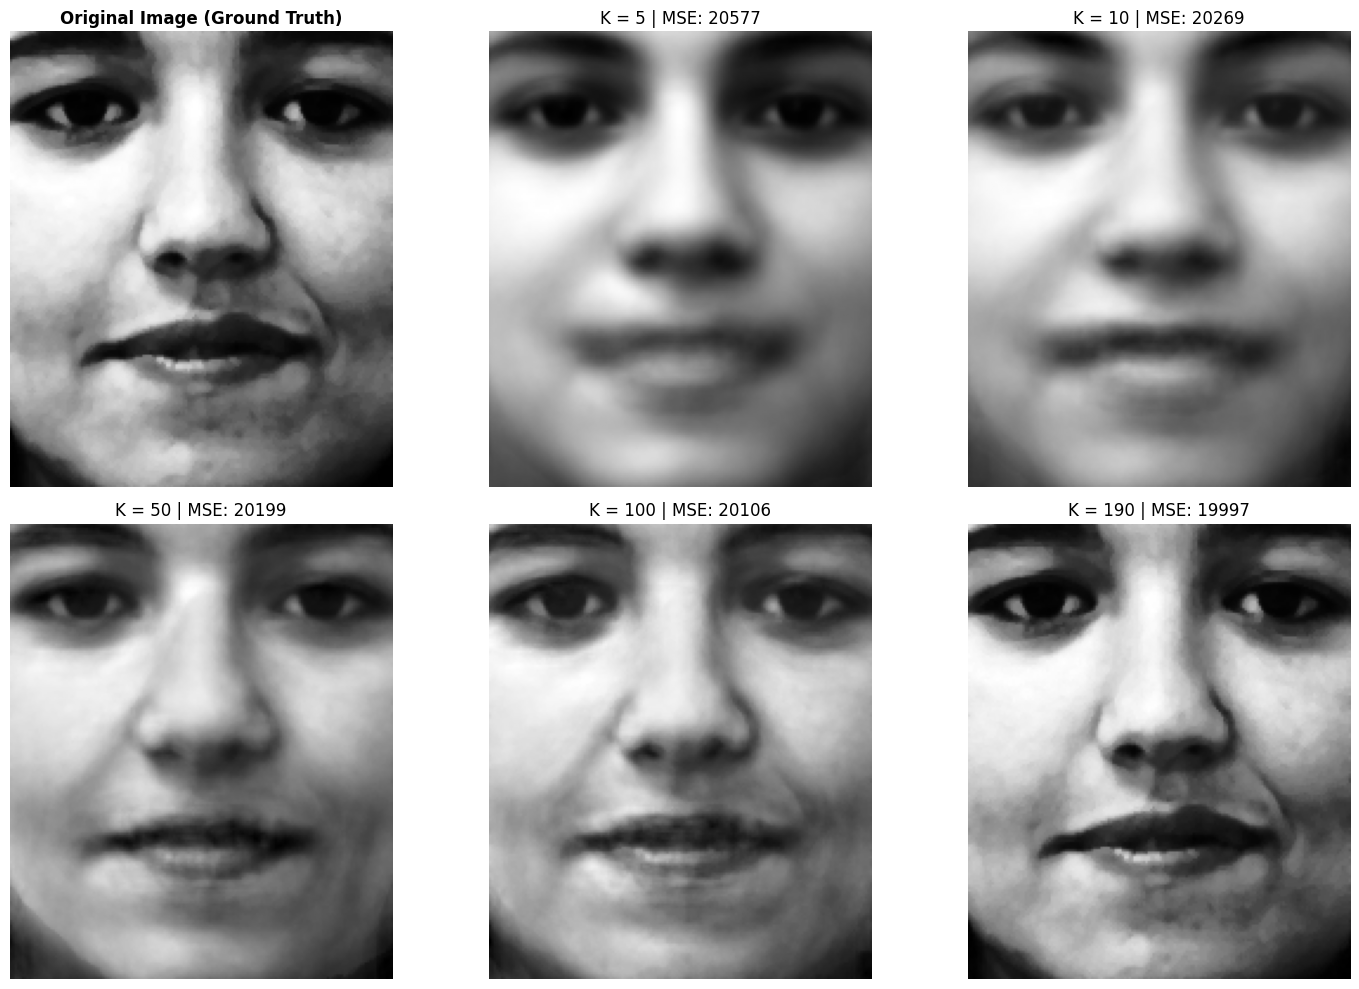

In [531]:
K_list = [5, 10, 50, 100, 190]

plt.figure(figsize=(15, 10))

img_index = 50
original_img_vector = final_matrix[:, img_index:img_index+1]

plt.subplot(2, 3, 1) 
ax_main = original_img_vector.reshape(193, 162)
plt.imshow(ax_main, cmap="gray")
plt.title("Original Image (Ground Truth)", fontsize=12, fontweight='bold')
plt.axis('off')

counter = 2
for k in K_list:
    eigenface = U_sorted[:, :k] 
    rec, mse_rec = reconstruct_image(original_img_vector, eigenface, mean_matrix)
    ax = rec.reshape(193, 162)
    
    
    plt.subplot(2, 3, counter)
    plt.imshow(ax, cmap="gray")
    plt.title(f"K = {k} | MSE: {mse_rec:.0f}", fontsize=12)
    plt.axis('off')
    
    counter += 1
    
plt.tight_layout()
plt.show()

##  Smiling  images (10 points)

<div dir="rtl" style="font-size:18px">
    حال این بار تمام کار‌هایی که در بخش قبل )بخش ب( انجام دادید را تکرار کنید. 
    ولی این بار به جای عکس‌های رندم از چهره‌های عادی، عکس رندم از چهره‌های خندان انتخاب کنید.
    نتایج خود را از کار‌هایی که این بخش انجام دادید و از روی خروجی‌های بدست آمده شرح دهید.
    به نظرتان دلایل تفاوت خروجی‌ها در هر قسمت نسبت به قسمت قبل چیست؟
<div/>

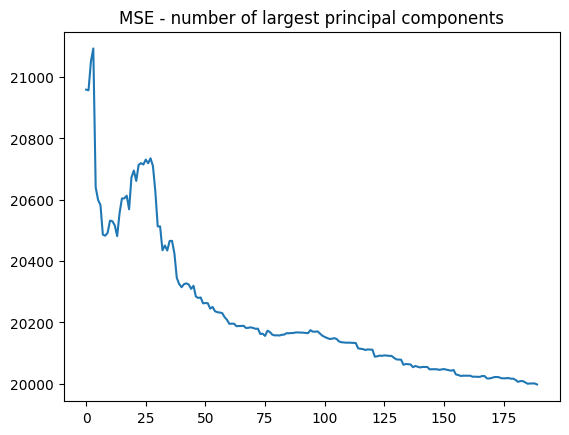

In [532]:
mse_list_laugh = []
for k in range(1,191):
    eigenface = U_sorted[:,:k]
    rec, mse_rec = reconstruct_image(final_matrix[:, 51:52] ,eigenface ,mean_matrix)
    mse_list_laugh.append(mse_rec)
# print(mse_list)
plt.title("MSE - number of largest principal components")
plt.plot(mse_list_laugh)

In [533]:
print(f"MAX mse k: {mse_list_laugh.index(max(mse_list_laugh))+1} with mse: {max(mse_list_laugh)}")
print(f"Min mse k: {mse_list_laugh.index(min(mse_list_laugh))+1} with mse: {min(mse_list_laugh)}")

MAX mse k: 4 with mse: 21093.0234375
Min mse k: 190 with mse: 19997.939453125


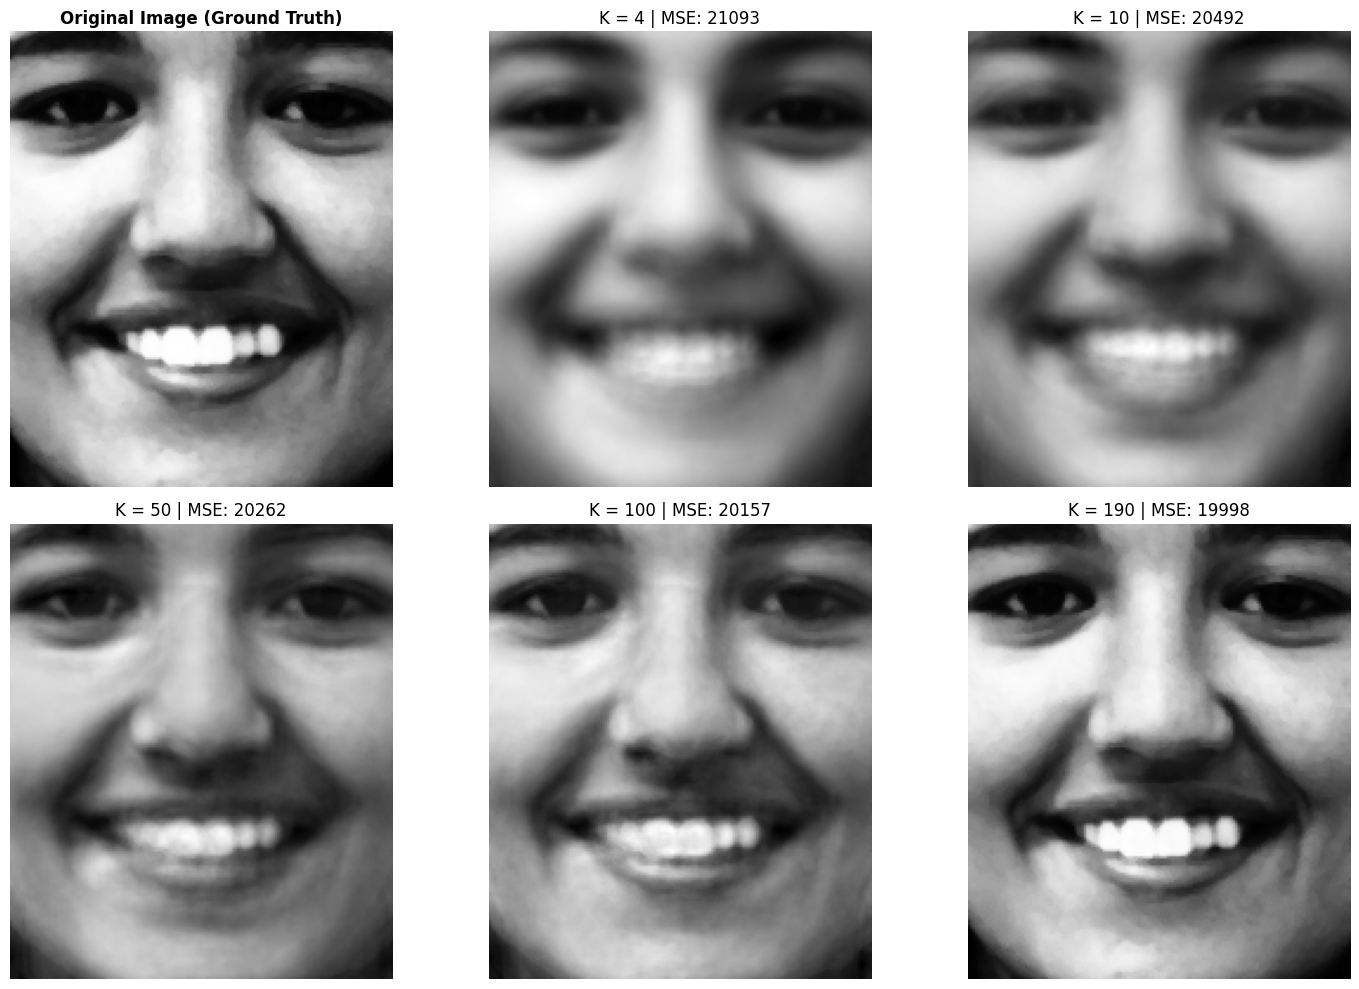

In [534]:
K_list = [4, 10, 50, 100, 190]

plt.figure(figsize=(15, 10))

img_index = 51
original_img_vector = final_matrix[:, img_index:img_index+1]

plt.subplot(2, 3, 1) 
ax_main = original_img_vector.reshape(193, 162)
plt.imshow(ax_main, cmap="gray")
plt.title("Original Image (Ground Truth)", fontsize=12, fontweight='bold')
plt.axis('off')

counter = 2
for k in K_list:
    eigenface = U_sorted[:, :k] 
    rec, mse_rec = reconstruct_image(original_img_vector, eigenface, mean_matrix)
    ax = rec.reshape(193, 162)
    
    
    plt.subplot(2, 3, counter)
    plt.imshow(ax, cmap="gray")
    plt.title(f"K = {k} | MSE: {mse_rec:.0f}", fontsize=12)
    plt.axis('off')
    
    counter += 1
    
plt.tight_layout()
plt.show()

## Reconstruction of test set (10 points)


<div dir="rtl" style="font-size:18px">
تا به اینجای کار ما با محاسبه MSE و بازسازی دوباره  عکس‌ها به  شهودی عددی و بصری از دقت فضای جدید یا همان  face space خود رسیدیم. اما نمی‌توان از این نکته چشم‌پوشی کرد که ارزیابی‌های ما از فضای جدید با استفاده از عکس‌هایی انجام شده که با آنها face space را ساخته‌ایم. در نتیجه این ارزیابی ما به نوعی biased است. برای ارزیابی بهتر MSE را بر روی تعدادی عکس که الگوریتم آنها را تا به حال ندیده است انجام داده و آنها را بازسازی می‌کنیم.
    <br/>
    در این قسمت یک عکس از ۱۰ عکس دیده نشده حالت طبیعی را انتخاب نموده و کارهای بخش ب را بر روی آن پیاده کنید. ارزیابی چه تفاوتی کرده است؟ نتیجه‌گیری کنید.
    <br/>
<div/>

In [535]:
NUM_IMAGES = 10
FEATURE_DIM = 31266

final_matrix_test = np.empty((FEATURE_DIM, NUM_IMAGES), dtype=np.float32, order='F')
i = 0
for each in directory[191:201]:
    if each.endswith('.jpg'):
        full_path = os.path.join('./datasets/', each)
        img = np.asarray(Image.open(full_path))
        flat = img.flatten()
        cols_flat = flat.T
        final_matrix_test[:, i] = cols_flat
        i+=1

final_matrix_test.shape

(31266, 10)

i dont change eigenface , mean_matrix because we want to test with new data

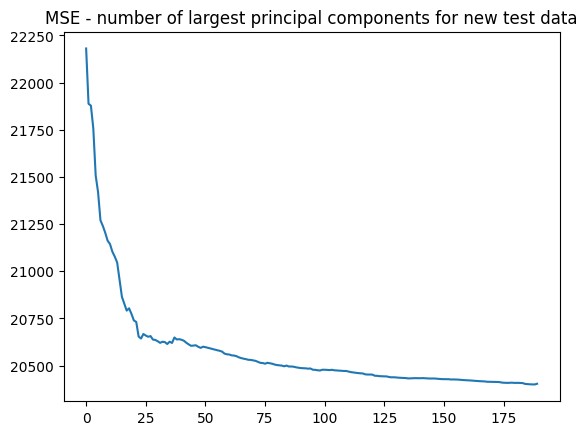

In [536]:
mse_list_test = []
for k in range(1,191):
    eigenface = U_sorted[:,:k]
    rec, mse_rec = reconstruct_image(final_matrix_test ,eigenface ,mean_matrix)
    mse_list_test.append(mse_rec)
# print(mse_list)
plt.title("MSE - number of largest principal components for new test data")
plt.plot(mse_list_test)

In [537]:
print(f"MAX mse k: {mse_list_test.index(max(mse_list_test))+1} with mse: {max(mse_list_test)}")
print(f"Min mse k: {mse_list_test.index(min(mse_list_test))+1} with mse: {min(mse_list_test)}")

MAX mse k: 1 with mse: 22180.81640625
Min mse k: 189 with mse: 20399.818359375


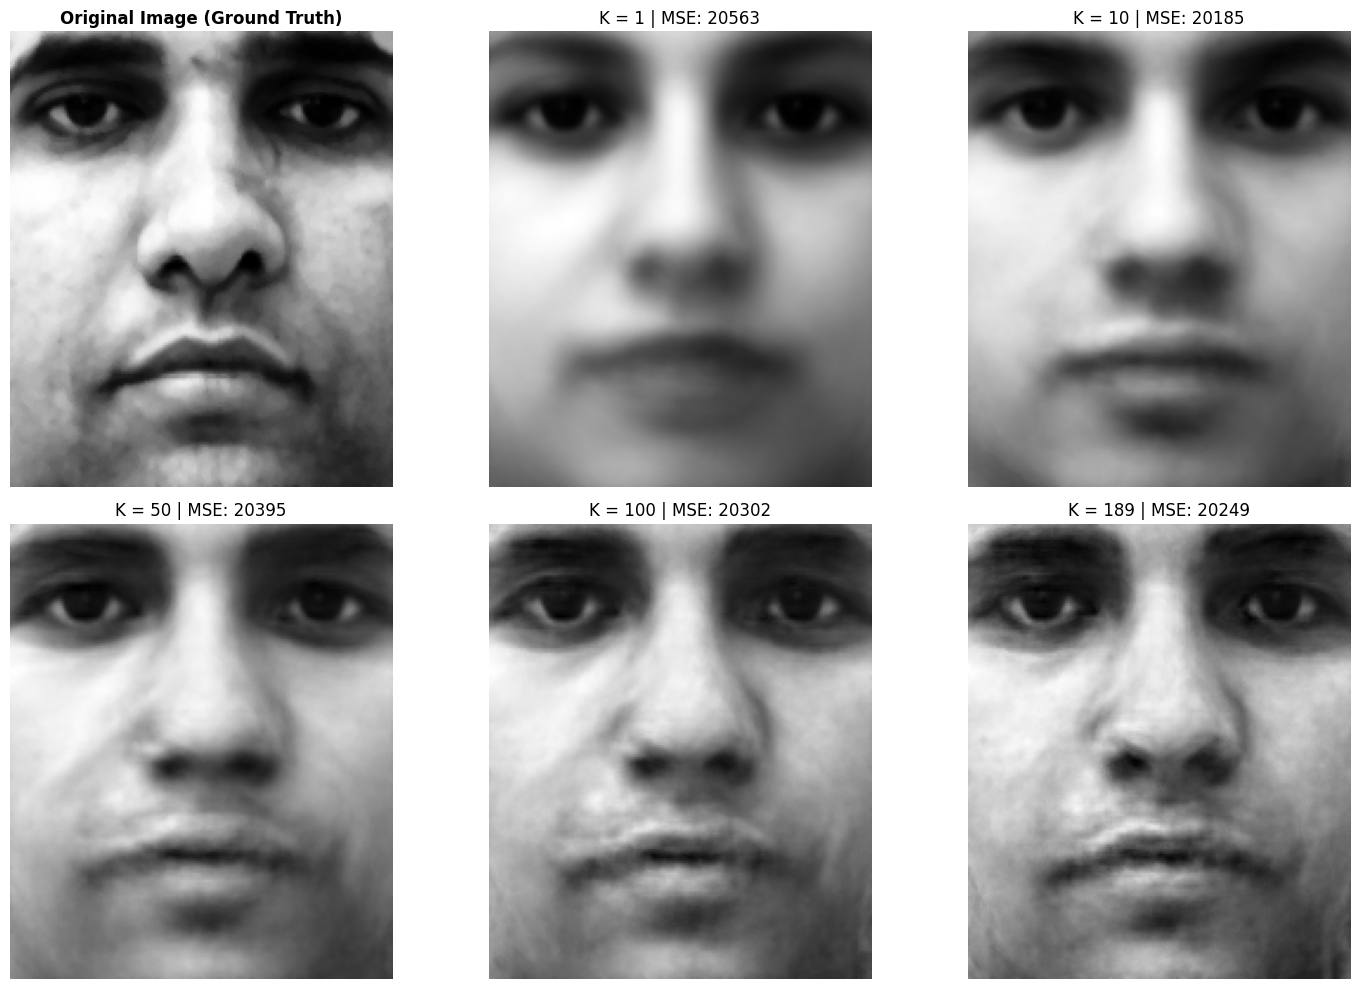

In [538]:
K_list = [1, 10, 50, 100, 189]

plt.figure(figsize=(15, 10))

img_index = 9
original_img_vector = final_matrix_test[:, img_index:img_index+1]

plt.subplot(2, 3, 1) 
ax_main = original_img_vector.reshape(193, 162)
plt.imshow(ax_main, cmap="gray")
plt.title("Original Image (Ground Truth)", fontsize=12, fontweight='bold')
plt.axis('off')

counter = 2
for k in K_list:
    eigenface = U_sorted[:, :k] 
    rec, mse_rec = reconstruct_image(original_img_vector, eigenface, mean_matrix)
    ax = rec.reshape(193, 162)
    
    
    plt.subplot(2, 3, counter)
    plt.imshow(ax, cmap="gray")
    plt.title(f"K = {k} | MSE: {mse_rec:.0f}", fontsize=12)
    plt.axis('off')
    
    counter += 1
    
plt.tight_layout()
plt.show()

## Reconstruction of non-human image (10 points)

<div dir="rtl" style="font-size:18px">
دو عکس غیر از چهره انسان و به دلخواه خود )مثل عکس ماشین یا پرنده( را در نظر گرفته.
    نخست عملیات‌های لازم مثل سیاه سفید کردن یا تغییر سایز را انجام دهید.
    سپس با استفاده از تمام PCها 
    سعی بر بازسازی آن داشته باشید و MSE را محاسبه نمایید.
    <br/>
    آیا الگوریتم به اندازه عکس چهره‌ها موفق عمل کرد؟‌ چرا؟ نتیجه‌گیری کنید.
    <br/>
<div/>

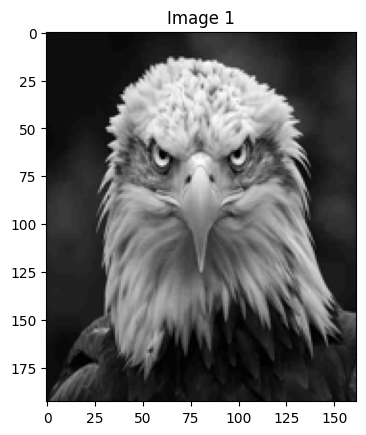

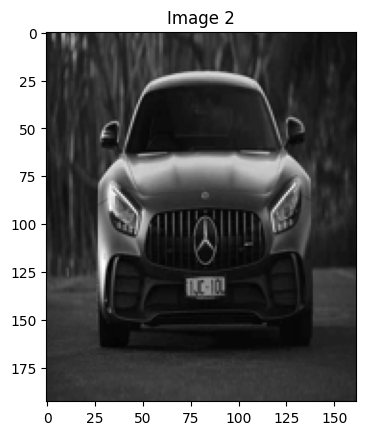

final matrix shape: (31266, 2)


In [539]:
image_paths = ['./eagleface.jpg','./benzfronview.jpg']
NUM_IMAGES = 2
FEATURE_DIM = 31266
RESIZE_DIM = (162,193)

final_matrix_test = np.empty((FEATURE_DIM, NUM_IMAGES), dtype=np.float32, order='F')

for i, path in enumerate(image_paths):
    
    img_pil = Image.open(path).convert('L').resize(RESIZE_DIM)
    img_array = np.asarray(img_pil)
    
    final_matrix_test[:, i] = img_array.flatten()
    
    plt.imshow(img_array, cmap="gray")
    plt.title(f"Image {i+1}")
    plt.show()

print(f"final matrix shape: {final_matrix_test.shape}")

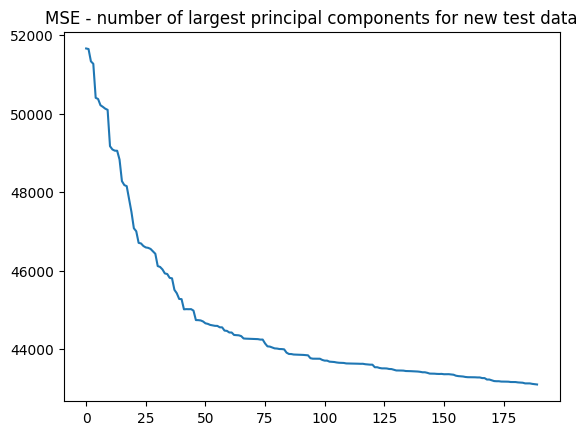

In [540]:
mse_list_test = []
for k in range(1,191):
    eigenface = U_sorted[:,:k]
    rec, mse_rec = reconstruct_image(final_matrix_test ,eigenface ,mean_matrix)
    mse_list_test.append(mse_rec)

plt.title("MSE - number of largest principal components for new test data")
plt.plot(mse_list_test)

In [541]:
print(f"MAX mse k: {mse_list_test.index(max(mse_list_test))+1} with mse: {max(mse_list_test)}")
print(f"Min mse k: {mse_list_test.index(min(mse_list_test))+1} with mse: {min(mse_list_test)}")

MAX mse k: 1 with mse: 51661.5546875
Min mse k: 190 with mse: 43095.44140625


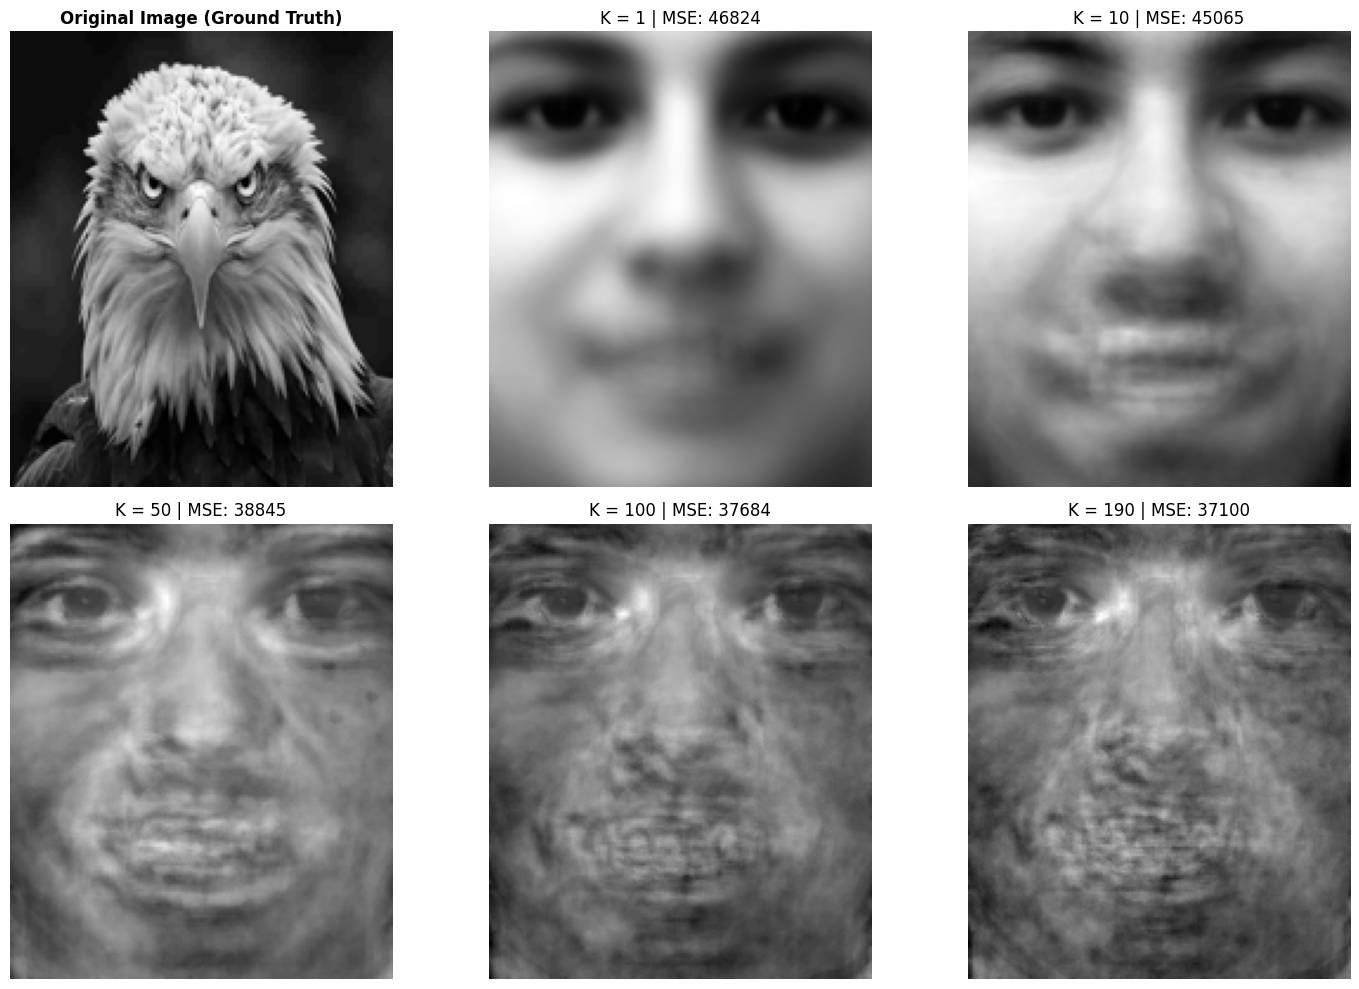

In [542]:
K_list = [1, 10, 50, 100, 190]

plt.figure(figsize=(15, 10))

img_index = 0
original_img_vector = final_matrix_test[:, img_index:img_index+1]

plt.subplot(2, 3, 1) 
ax_main = original_img_vector.reshape(193, 162)
plt.imshow(ax_main, cmap="gray")
plt.title("Original Image (Ground Truth)", fontsize=12, fontweight='bold')
plt.axis('off')

counter = 2
for k in K_list:
    eigenface = U_sorted[:, :k] 
    rec, mse_rec = reconstruct_image(original_img_vector, eigenface, mean_matrix)
    ax = rec.reshape(193, 162)
    
    
    plt.subplot(2, 3, counter)
    plt.imshow(ax, cmap="gray")
    plt.title(f"K = {k} | MSE: {mse_rec:.0f}", fontsize=12)
    plt.axis('off')
    
    counter += 1
    
plt.tight_layout()
plt.show()

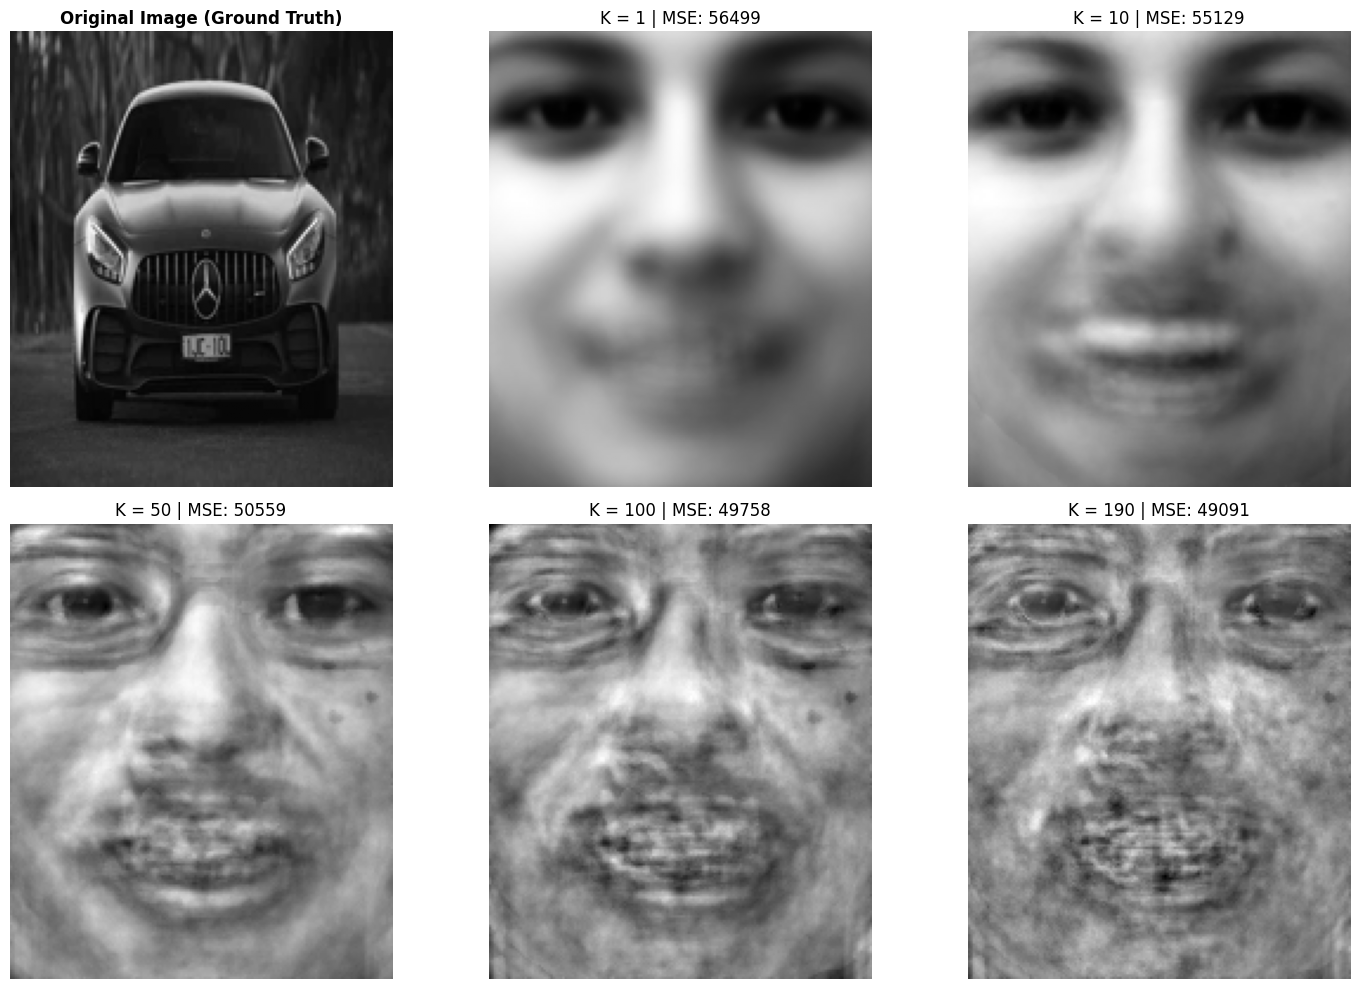

In [543]:
K_list = [1, 10, 50, 100, 190]

plt.figure(figsize=(15, 10))

img_index = 1
original_img_vector = final_matrix_test[:, img_index:img_index+1]

plt.subplot(2, 3, 1) 
ax_main = original_img_vector.reshape(193, 162)
plt.imshow(ax_main, cmap="gray")
plt.title("Original Image (Ground Truth)", fontsize=12, fontweight='bold')
plt.axis('off')

counter = 2
for k in K_list:
    eigenface = U_sorted[:, :k] 
    rec, mse_rec = reconstruct_image(original_img_vector, eigenface, mean_matrix)
    ax = rec.reshape(193, 162)
    
    
    plt.subplot(2, 3, counter)
    plt.imshow(ax, cmap="gray")
    plt.title(f"K = {k} | MSE: {mse_rec:.0f}", fontsize=12)
    plt.axis('off')
    
    counter += 1
    
plt.tight_layout()
plt.show()

## Image Rotation (10 points)

<div dir="rtl" style="font-size:18px">
    حال یکی از عکس‌های دیتاستی که تا الان روی آن کار کردیم )شامل 190 عکس طبیعی( را به صورت رندم انتخاب کنید. برای آن عکس تمام rotationهای ممکن
    )از 0 تا 360( را انجام دهید.
    حال روی هر یک از عکس‌های بدست آمده با استفاده از تمام PCها عملیات بازسازی و محاسبه‌ی MSE را انجام دهید.
    <br/>
    نمودار MSE بر حسب درجه‌ی چرخش را رسم کنید.
    <br/>
    برای 10 درجه به صورت یکنواخت بین 360 و 0، عکس اصلی، عکس بعد از دوران، عکس بازسازی‌شده به کمک الگوریتم را رسم کنید.
    <br/>
    نتایج به دست آمده را تحلیل کنید. آیا MSE در حالت 360 درجه دوران با حالت 0 برابر است؟
    چرا؟
    <br/>
    <br/>
    <font color=blue>
    با استفاده از ndimage میتوانید عکس های خود را بچرخانید.
        <font/>
        <br/>
<div/>

In [544]:
K_optimal = 50
eigenface_k = U_sorted[:, :K_optimal]
eigenface_k

array([[-0.00267712,  0.00072696, -0.00042601, ..., -0.0159824 ,
         0.01258057,  0.01002002],
       [-0.00305354,  0.00130756,  0.00094697, ..., -0.01850568,
         0.01450171,  0.01079727],
       [-0.00337639,  0.0007179 ,  0.00288641, ..., -0.01821636,
         0.0160615 ,  0.01234539],
       ...,
       [ 0.00209708, -0.00857167, -0.00147782, ..., -0.00155579,
         0.00710726, -0.00496994],
       [ 0.00223237, -0.00831534, -0.00218086, ..., -0.00040953,
         0.0061193 , -0.00696257],
       [ 0.00214237, -0.00813344, -0.00254842, ...,  0.00036631,
         0.00501109, -0.00867253]], shape=(31266, 50), dtype=float32)

In [545]:
img_index = 50 
original_img_1d = final_matrix[:, img_index:img_index+1]
original_img_2d = original_img_1d.reshape(193, 162)

angles = range(0, 361, 15)
mse_list_rotation = []
for theta in angles:
    rotated_img_2d = rotate(original_img_2d, angle=theta, reshape=False)
    
    rotated_img_1d = rotated_img_2d.reshape(-1, 1)
    rec_img, current_mse = reconstruct_image(rotated_img_1d, eigenface_k, mean_matrix)
    
    mse_list_rotation.append(current_mse)

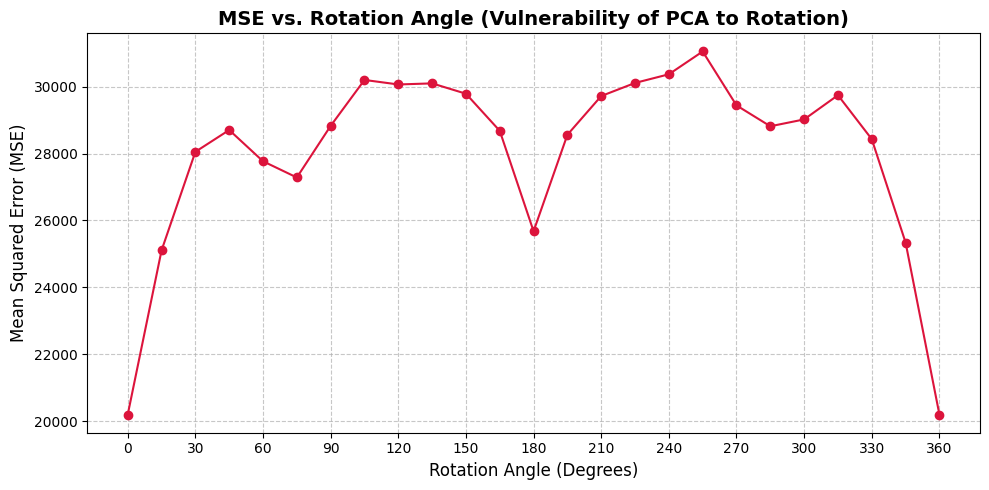

In [546]:
plt.figure(figsize=(10, 5))
plt.plot(angles, mse_list_rotation, marker='o', linestyle='-', color='crimson')

plt.title("MSE vs. Rotation Angle (Vulnerability of PCA to Rotation)", fontsize=14, fontweight='bold')
plt.xlabel("Rotation Angle (Degrees)", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.xticks(np.arange(0, 361, 30))
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

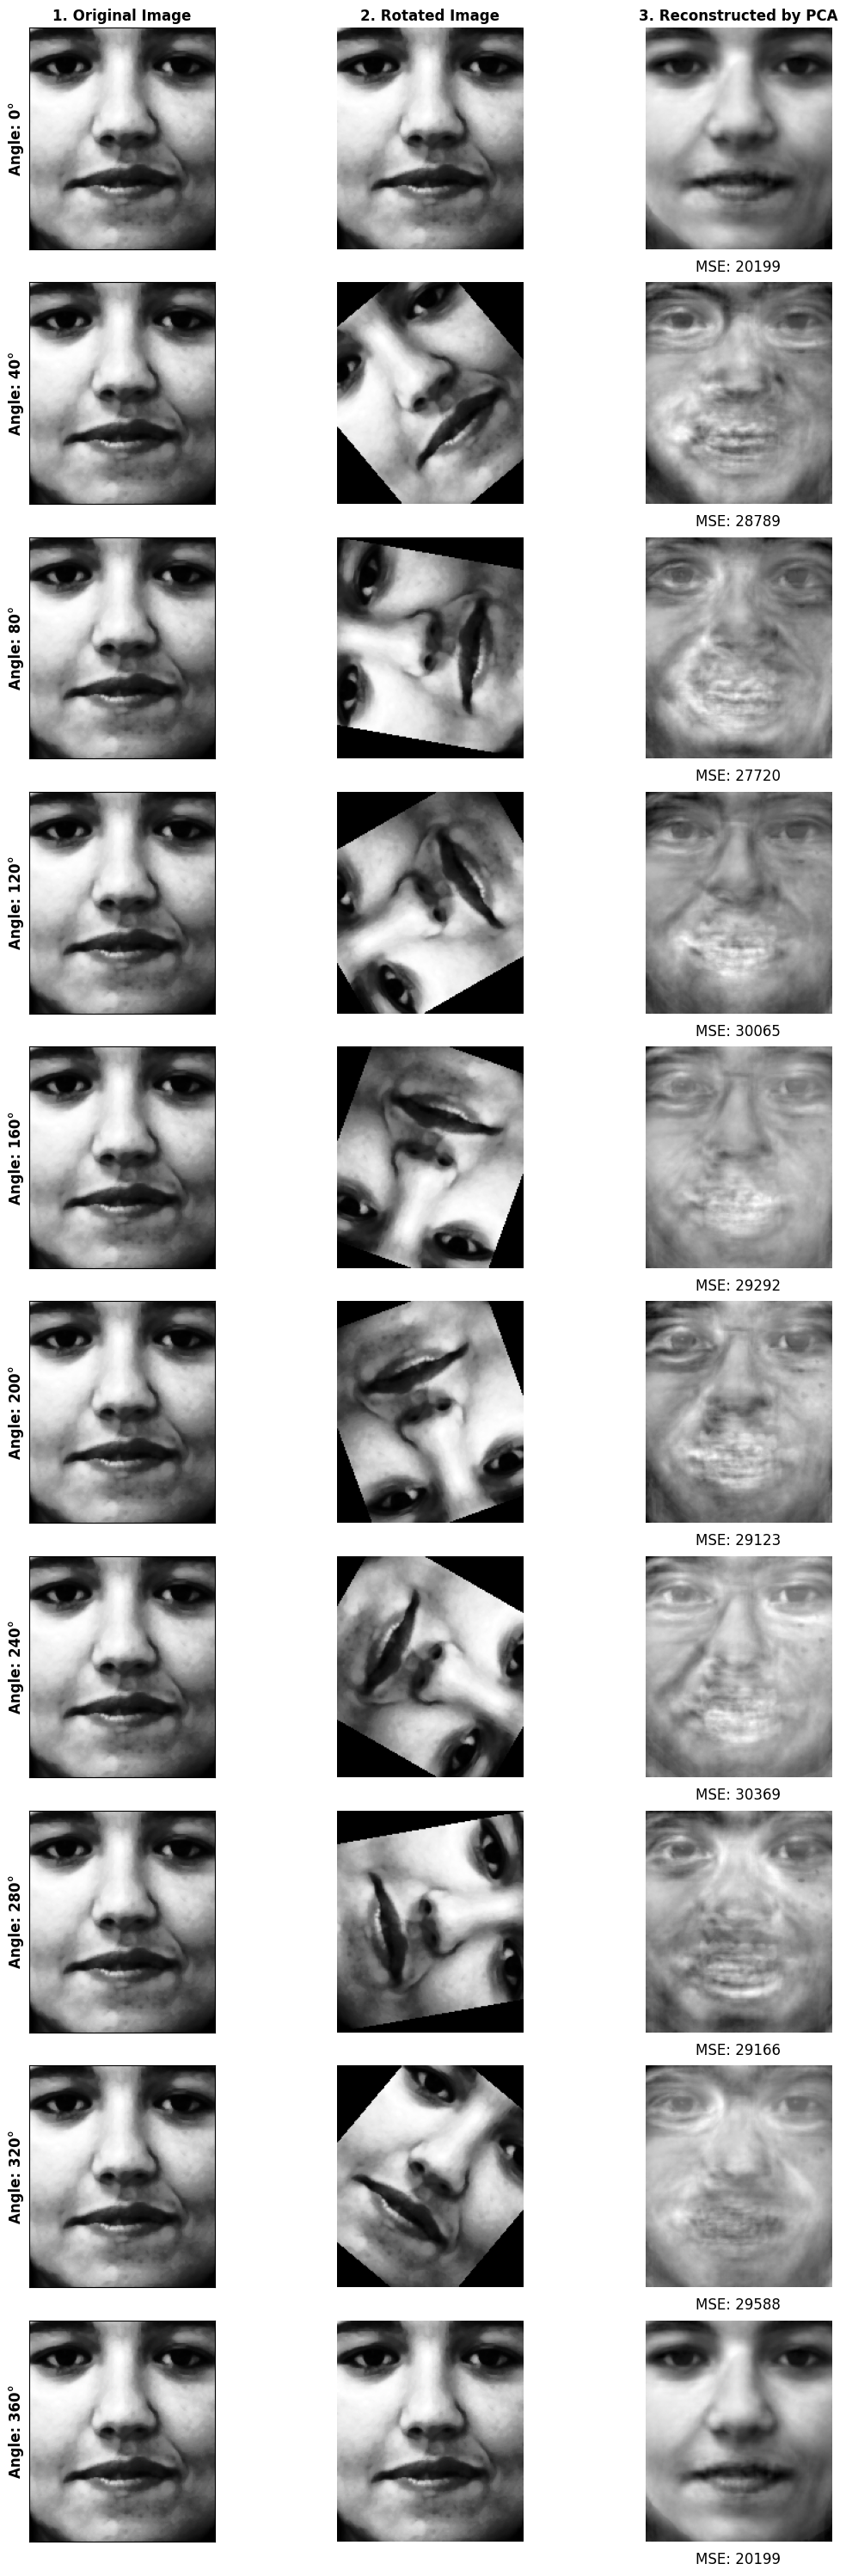

In [547]:
K_optimal = 50
eigenface_k = U_sorted[:, :K_optimal]


img_index = 50
original_img_1d = final_matrix[:, img_index:img_index+1]
original_img_2d = original_img_1d.reshape(193, 162)


angles = np.linspace(0, 360, 10)
plt.figure(figsize=(12, 30))

for i, theta in enumerate(angles):
    
    rotated_img_2d = rotate(original_img_2d, angle=theta, reshape=False)
    
    rotated_img_1d = rotated_img_2d.reshape(-1, 1)
    
    rec_img_1d, mse_val = reconstruct_image(rotated_img_1d, eigenface_k, mean_matrix)
    rec_img_2d = rec_img_1d.reshape(193, 162)
    
    plt.subplot(10, 3, i * 3 + 1)
    plt.imshow(original_img_2d, cmap="gray")
    if i == 0: plt.title("1. Original Image", fontsize=12, fontweight='bold')
    plt.ylabel(f"Angle: {theta:.0f}°", fontsize=12, fontweight='bold')
    plt.xticks([])
    plt.yticks([])
    
    plt.subplot(10, 3, i * 3 + 2)
    plt.imshow(rotated_img_2d, cmap="gray")
    if i == 0: plt.title("2. Rotated Image", fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(10, 3, i * 3 + 3)
    plt.imshow(rec_img_2d, cmap="gray")
    if i == 0: plt.title("3. Reconstructed by PCA", fontsize=12, fontweight='bold')
    
    plt.text(0.5, -0.1, f"MSE: {mse_val:.0f}", size=12, ha="center", transform=plt.gca().transAxes)
    plt.axis('off')


plt.tight_layout()
plt.show()

the angle of 0 and 360 is equal because the image is in the same spot and give us the same result.